# 11 — Results overview

First-pass exploration of the bundled HPC results: per-pair effect sizes, example L(r) curves, and ligand × receptor heatmaps per strip.

Inputs:
- `results/lr_panel_results.parquet` — one row per (ligand, receptor, strip)
- `results/lr_panel_results.parquet.r_vals.npy` — 50-point radii vector


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.rcParams['figure.dpi'] = 110

In [2]:
RESULTS = '../results/lr_panel_results.parquet'
RVALS   = RESULTS + '.r_vals.npy'

df = pd.read_parquet(RESULTS)
r_vals = np.load(RVALS)

# Stored as Python lists in parquet — promote to numpy arrays for vector math
for col in ('l_obs', 'l_lo', 'l_hi'):
    df[col] = df[col].apply(np.asarray)

print(f'rows:        {len(df)}')
print(f'unique pairs:{df[["ligand","receptor"]].drop_duplicates().shape[0]}')
print(f'strips:      {sorted(df.strip.unique())}')
print(f'r_vals:      {len(r_vals)} points, {r_vals[0]:.1f} -> {r_vals[-1]:.1f} px')
df.head(3)

rows:        438
unique pairs:146
strips:      ['strip_1', 'strip_2', 'strip_3']
r_vals:      50 points, 5.0 -> 250.0 px


,ligand,receptor,strip,n_a,n_b,l_obs,l_lo,l_hi,window_type,window_area_px2,status
0,DLL1,NOTCH1,strip_1,253,188,"[6.682699702364442, 5.130975564433407, 3.57925...","[33.74713145113956, 32.19540731320853, 34.0191...","[54.5703137538009, 53.01858961586987, 53.71558...",concave,20394576,ok
1,DLL1,NOTCH1,strip_2,169,101,"[-5.0, -6.551724137931035, -8.10344827586207, ...","[17.59721078569302, 21.124093879601187, 23.853...","[50.351636035064445, 51.06008523657799, 53.781...",concave,13691078,ok
2,DLL1,NOTCH1,strip_3,189,155,"[18.493215515073395, 16.94149137714236, 15.389...","[23.773195214583453, 22.221471076652417, 20.66...","[48.8297192078674, 47.27799506993637, 46.99302...",concave,12698964,ok


## 2. Data overview

In [3]:
print('Status counts:')
print(df.status.value_counts())
print()
print('Per-strip row counts:')
print(df.strip.value_counts().sort_index())
print()
print('Failed pairs (if any):')
print(df[df.status != 'ok'][['ligand','receptor','strip','status']])

Status counts:
status
ok    438
Name: count, dtype: int64

Per-strip row counts:
strip
strip_1    146
strip_2    146
strip_3    146
Name: count, dtype: int64

Failed pairs (if any):
Empty DataFrame
Columns: [ligand, receptor, strip, status]
Index: []


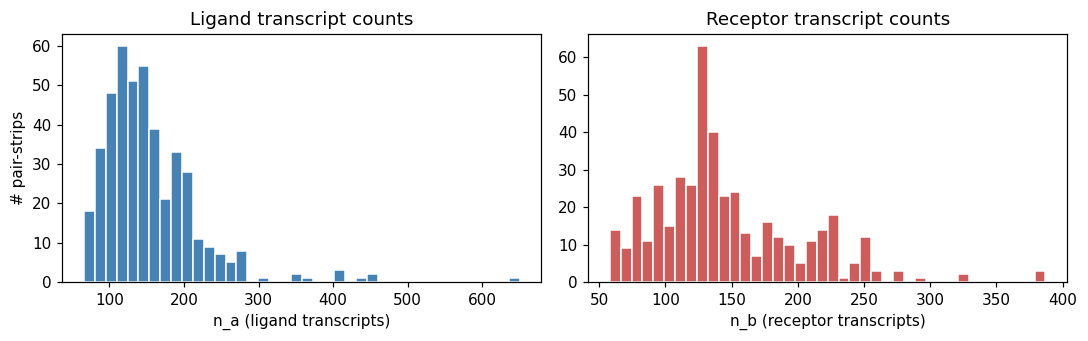

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

axes[0].hist(df.n_a, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('n_a (ligand transcripts)')
axes[0].set_ylabel('# pair-strips')
axes[0].set_title('Ligand transcript counts')

axes[1].hist(df.n_b, bins=40, color='indianred', edgecolor='white')
axes[1].set_xlabel('n_b (receptor transcripts)')
axes[1].set_title('Receptor transcript counts')

plt.tight_layout()
plt.show()

## 3. Per-pair effect size

Pointwise signed standardised effect size:

$$\mathrm{SES}(r) = \frac{L_\mathrm{obs}(r) - \mathrm{midline}(r)}{\mathrm{halfwidth}(r)}$$

where `midline = (l_hi + l_lo) / 2` and `halfwidth = (l_hi - l_lo) / 2`.

The pair-level **score** is the SES value at the radius of greatest |SES|.
Positive ⇒ attraction beyond the permutation envelope; negative ⇒ depletion below it. |score| > 1 indicates excursion outside the envelope at that radius.

In [5]:
mid  = df.apply(lambda r: (r.l_hi + r.l_lo) / 2, axis=1)
half = df.apply(lambda r: (r.l_hi - r.l_lo) / 2, axis=1)

# Pointwise SES; guard against envelope collapse (zero halfwidth)
df['ses_curve'] = [
    np.where(h > 1e-9, (obs - m) / h, 0.0)
    for obs, m, h in zip(df.l_obs, mid, half)
]

def peak_signed(ses):
    i = int(np.argmax(np.abs(ses)))
    return float(ses[i])

df['score']     = df.ses_curve.apply(peak_signed)
df['r_at_peak'] = df.ses_curve.apply(lambda s: float(r_vals[int(np.argmax(np.abs(s)))]))

df[['ligand','receptor','strip','n_a','n_b','score','r_at_peak']].describe().round(2)

,n_a,n_b,score,r_at_peak
count,438.00,438.00,438.00,438.00
mean,153.71,145.98,-2.32,13.62
std,64.53,54.81,1.06,28.26
min,66.00,58.00,-6.00,5.00
25%,113.00,110.25,-3.00,5.00
50%,141.00,135.00,-2.29,6.55
75%,184.50,177.00,-1.53,9.66
max,650.00,387.00,1.39,250.00


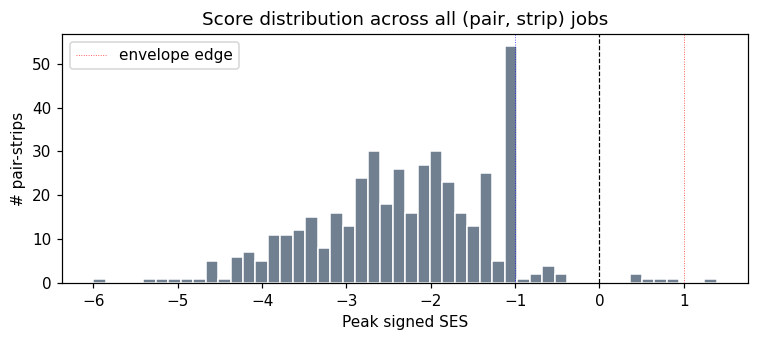

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(df.score, bins=50, color='slategrey', edgecolor='white')
ax.axvline( 0, color='black', lw=0.8, ls='--')
ax.axvline( 1, color='red',   lw=0.6, ls=':', alpha=0.7, label='envelope edge')
ax.axvline(-1, color='blue',  lw=0.6, ls=':', alpha=0.7)
ax.set_xlabel('Peak signed SES')
ax.set_ylabel('# pair-strips')
ax.set_title('Score distribution across all (pair, strip) jobs')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Example L(r) curves

Six examples spanning the score range: 2 strongest attraction, 2 near-null, 2 strongest depletion (or weakest attraction if no real depletion).
Shaded band = permutation envelope `[l_lo, l_hi]`. Dashed grey = midline.

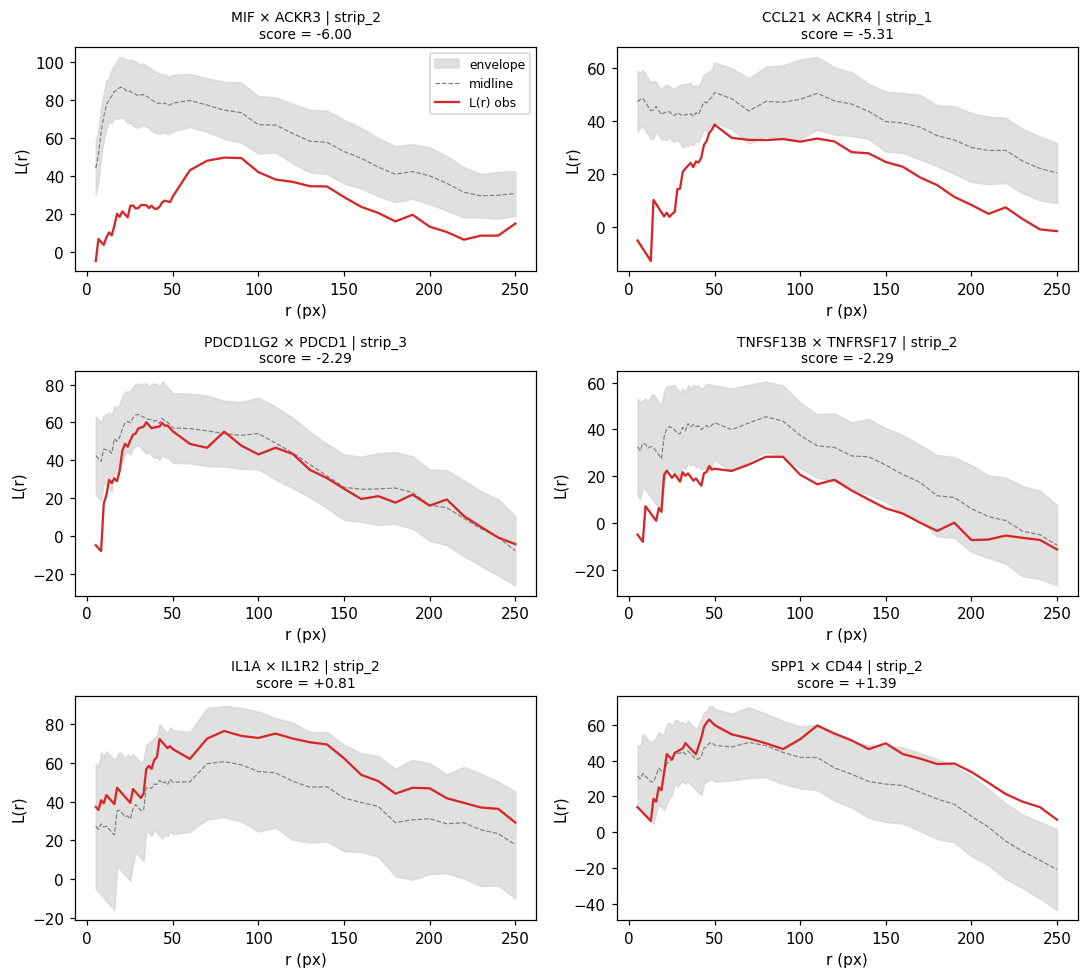

In [7]:
def plot_lr(ax, row, r_vals):
    ax.fill_between(r_vals, row.l_lo, row.l_hi, color='lightgrey', alpha=0.7, label='envelope')
    mid = (row.l_hi + row.l_lo) / 2
    ax.plot(r_vals, mid,       color='grey', lw=0.8, ls='--', label='midline')
    ax.plot(r_vals, row.l_obs, color='C3',   lw=1.5,         label='L(r) obs')
    ax.set_title(f'{row.ligand} × {row.receptor} | {row.strip}\nscore = {row.score:+.2f}', fontsize=9)
    ax.set_xlabel('r (px)')
    ax.set_ylabel('L(r)')

ok = df[df.status == 'ok'].sort_values('score').reset_index(drop=True)
mid_i = len(ok) // 2
picks = pd.concat([ok.head(2), ok.iloc[mid_i-1:mid_i+1], ok.tail(2)])

fig, axes = plt.subplots(3, 2, figsize=(10, 9))
for ax, (_, row) in zip(axes.ravel(), picks.iterrows()):
    plot_lr(ax, row, r_vals)
axes[0, 0].legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

## 5. Top pairs across all strips

For the 4 pairs with the largest mean |score| across strips, plot all three strips on the same axes.
Distinct colours per strip; lighter shading = envelope, solid line = observed.

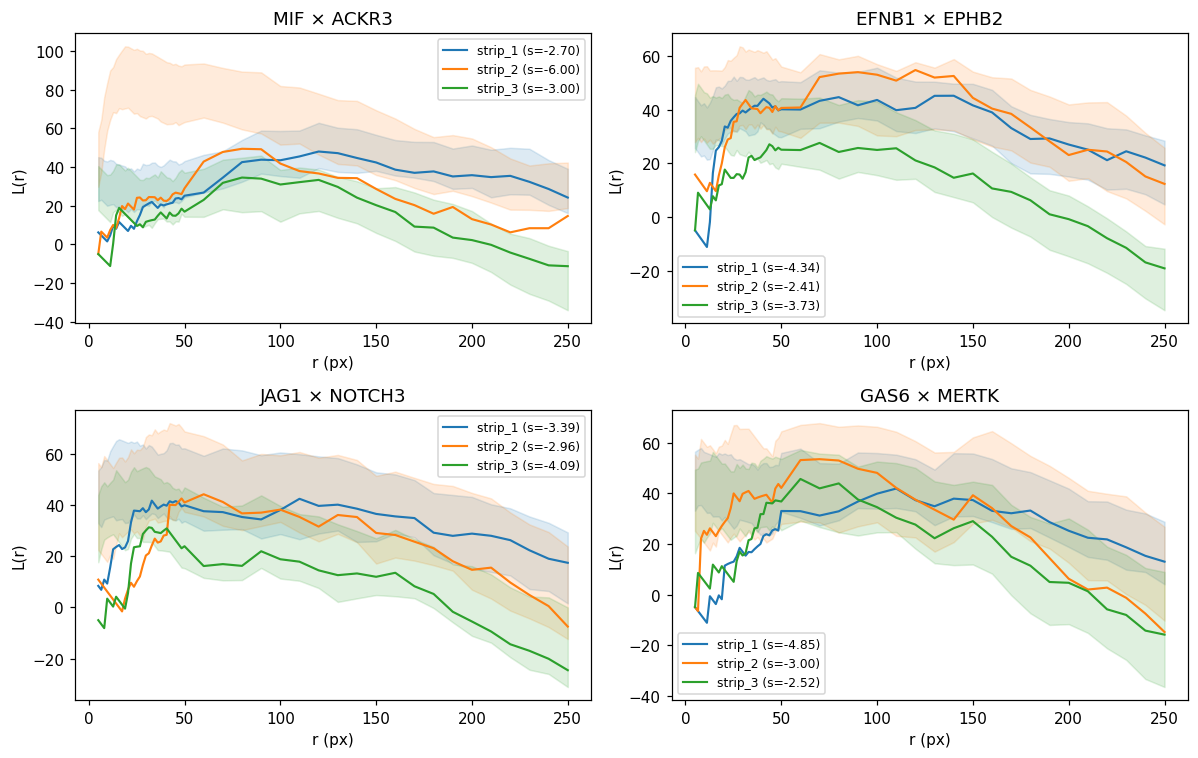

In [8]:
pair_score = (df.groupby(['ligand', 'receptor'])
                .score.apply(lambda s: np.mean(np.abs(s)))
                .sort_values(ascending=False))
top_pairs = pair_score.head(4).index.tolist()

strip_colors = {'strip_1': 'C0', 'strip_2': 'C1', 'strip_3': 'C2'}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (lig, rec) in zip(axes.ravel(), top_pairs):
    sub = df[(df.ligand == lig) & (df.receptor == rec)]
    for _, row in sub.iterrows():
        c = strip_colors.get(row.strip, 'grey')
        ax.fill_between(r_vals, row.l_lo, row.l_hi, color=c, alpha=0.15)
        ax.plot(r_vals, row.l_obs, color=c, lw=1.4,
                label=f'{row.strip} (s={row.score:+.2f})')
    ax.set_title(f'{lig} × {rec}')
    ax.set_xlabel('r (px)')
    ax.set_ylabel('L(r)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Ligand × receptor heatmaps per strip

One panel per strip. Rows = ligands, columns = receptors, ordered by mean |score| across strips so the strongest signals cluster top-left.

Cell colour = peak signed SES — **red = attraction, blue = depletion**. Light grey cells indicate pairs not in the curated panel (no measurement), distinct from cells with measured-but-null score.

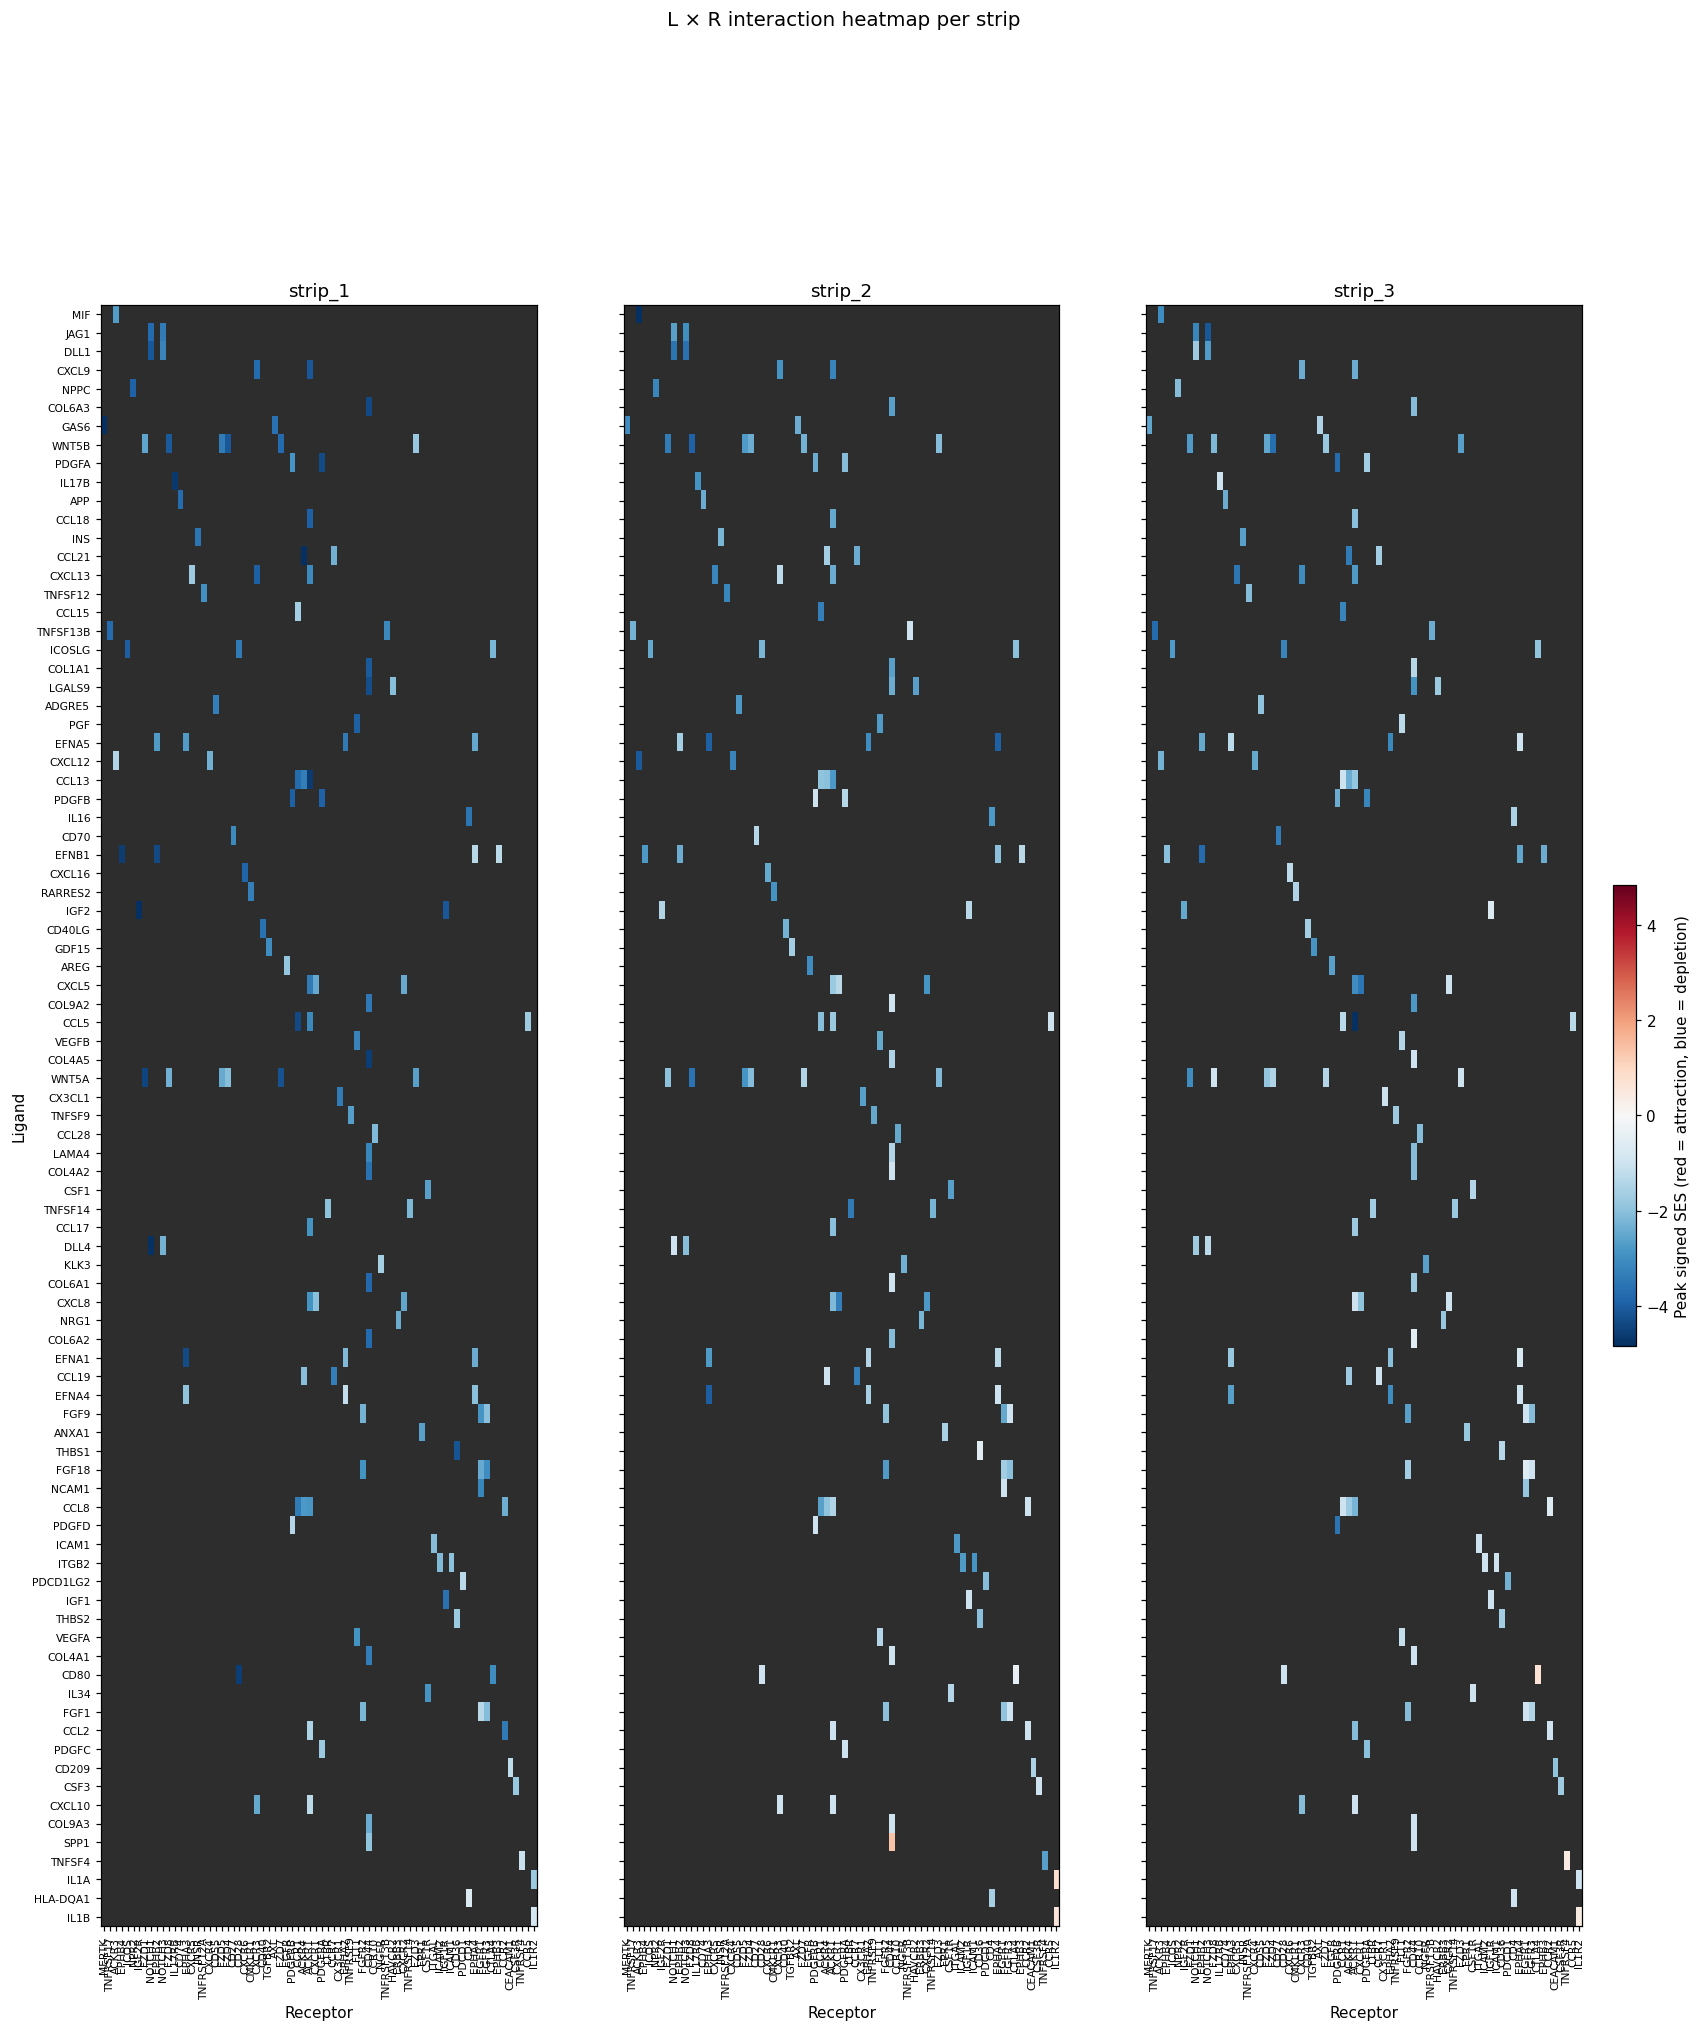

In [9]:
strips = sorted(df.strip.unique())

# Global ordering — mean |score| across strips
lig_order = (df.groupby('ligand').score.apply(lambda s: np.mean(np.abs(s)))
               .sort_values(ascending=False).index.tolist())
rec_order = (df.groupby('receptor').score.apply(lambda s: np.mean(np.abs(s)))
               .sort_values(ascending=False).index.tolist())

mats = {}
for s in strips:
    mats[s] = (df[df.strip == s]
               .pivot(index='ligand', columns='receptor', values='score')
               .reindex(index=lig_order, columns=rec_order))

# Symmetric colour limit — 99th percentile to keep one outlier from flattening the scale
vlim = float(np.percentile(np.abs(df.score.dropna()), 99))
norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

fig_h = max(6, len(lig_order) * 0.22)
fig, axes = plt.subplots(1, 3, figsize=(18, fig_h), sharey=True)

for ax, s in zip(axes, strips):
    M = mats[s].to_numpy(dtype=float)
    # Grey background for unmeasured cells
    nan_mask = np.isnan(M)
    bg = np.where(nan_mask, 0.85, np.nan)
    ax.imshow(bg, cmap='Greys', vmin=0, vmax=1, aspect='auto')
    # Score on top
    im = ax.imshow(M, cmap='RdBu_r', norm=norm, aspect='auto')
    ax.set_title(s)
    ax.set_xticks(range(len(rec_order)))
    ax.set_xticklabels(rec_order, rotation=90, fontsize=7)
    ax.set_yticks(range(len(lig_order)))
    ax.set_yticklabels(lig_order, fontsize=7)
    ax.set_xlabel('Receptor')
axes[0].set_ylabel('Ligand')

cbar = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02)
cbar.set_label('Peak signed SES (red = attraction, blue = depletion)')

plt.suptitle('L × R interaction heatmap per strip', y=1.02, fontsize=13)
plt.show()